# Evaluación Parcial N°1 — Fundamentos de Deep Learning
## Clasificación de Fashion-MNIST mediante una Red Neuronal Multicapa (MLP)

**Asignatura:** DLY0100 Deep Learning  
**Dataset:** Fashion-MNIST  
**Framework:** TensorFlow / Keras  
**Objetivo:** construir, entrenar, comparar y mejorar una MLP para clasificación de imágenes.

### Relación con la rúbrica
Este notebook documenta:
- carga y preprocesamiento de datos;
- visualización de ejemplos del dataset;
- arquitectura MLP y funciones de activación/salida;
- experimentos controlados de **batch size, learning rate y número de épocas**;
- comparación de funciones de pérdida;
- comparación de funciones de activación;
- regularización mediante **Dropout** y **L2**;
- **Batch Normalization**;
- comparación con y sin optimización/regularización;
- métricas **Accuracy, Precision, Recall y F1-Score**;
- tablas y gráficos comparativos;
- selección y evaluación del modelo final;
- conclusiones basadas en los resultados obtenidos.

> **Nota:** los resultados numéricos se generan al ejecutar el notebook. No se escriben manualmente, para que las conclusiones estén respaldadas por los experimentos.

## 1. Importación de librerías y configuración

Se utilizan TensorFlow/Keras para construir y entrenar la MLP, Scikit-learn para las métricas y partición estratificada, y Matplotlib/Seaborn para las visualizaciones solicitadas.

In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: []


## 2. Carga y preprocesamiento de Fashion-MNIST

Fashion-MNIST contiene imágenes de 28×28 píxeles pertenecientes a 10 categorías de prendas y accesorios.

El preprocesamiento utilizado es:

1. cargar el dataset desde `tf.keras.datasets.fashion_mnist`;
2. reservar el conjunto de prueba;
3. separar el conjunto de entrenamiento en entrenamiento y validación usando `stratify`;
4. convertir las imágenes de 28×28 a vectores de 784 características, porque la MLP recibe entradas vectoriales;
5. convertir los valores de píxel de `[0,255]` a `[0,1]`.

La normalización facilita el entrenamiento porque mantiene las entradas en una escala pequeña y homogénea.

In [2]:
# Carga del dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()

# División estratificada: 80% entrenamiento, 20% validación
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_raw
)

# Aplanado y normalización
X_train = X_train_raw.reshape(-1, 784).astype("float32") / 255.0
X_val   = X_val_raw.reshape(-1, 784).astype("float32") / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype("float32") / 255.0

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Rango X_train:", X_train.min(), "a", X_train.max())

# Verificación de distribución de clases
dist = pd.DataFrame({
    "Clase": class_names,
    "Train": np.bincount(y_train),
    "Validation": np.bincount(y_val),
    "Test": np.bincount(y_test)
})
display(dist)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (48000, 784) (48000,)
Validation: (12000, 784) (12000,)
Test: (10000, 784) (10000,)
Rango X_train: 0.0 a 1.0


,Clase,Train,Validation,Test
0,T-shirt/top,4800,1200,1000
1,Trouser,4800,1200,1000
2,Pullover,4800,1200,1000
3,Dress,4800,1200,1000
4,Coat,4800,1200,1000
5,Sandal,4800,1200,1000
6,Shirt,4800,1200,1000
7,Sneaker,4800,1200,1000
8,Bag,4800,1200,1000
9,Ankle boot,4800,1200,1000


### 2.1 Visualización de imágenes

Esta visualización permite comprobar que los datos fueron cargados correctamente y sirve como evidencia visual del problema de clasificación.

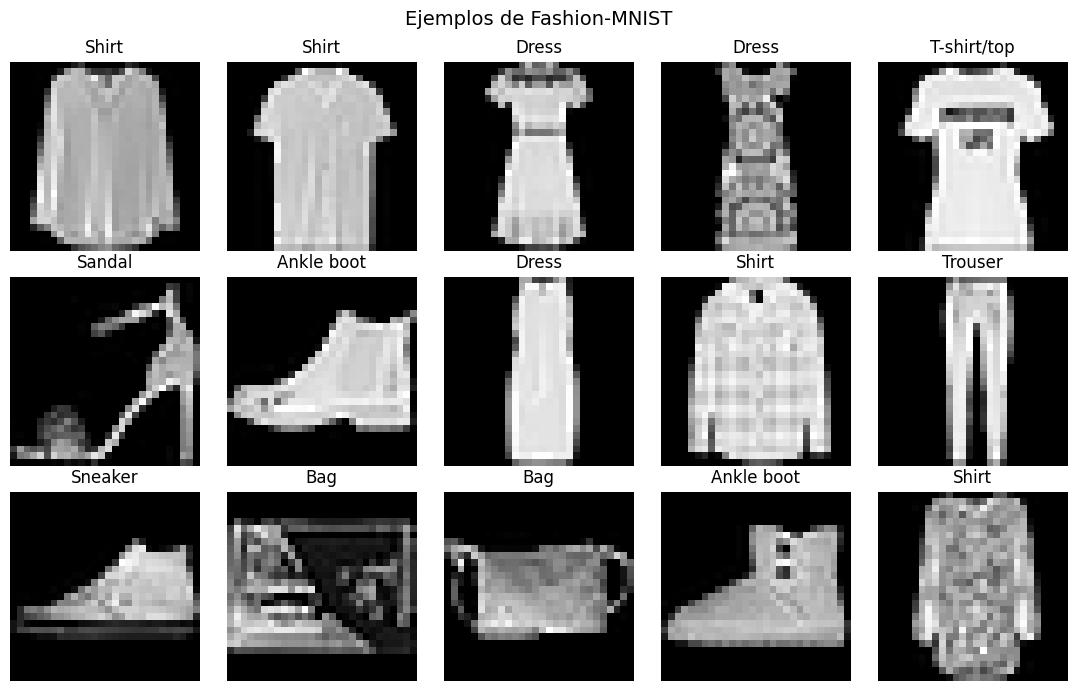

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for ax, idx in zip(axes.ravel(), range(15)):
    ax.imshow(X_train_raw[idx], cmap="gray")
    ax.set_title(class_names[y_train[idx]])
    ax.axis("off")
plt.suptitle("Ejemplos de Fashion-MNIST", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Funciones fundamentales: activación, salida y pérdida

En las capas ocultas se comparan **ReLU, Sigmoid y LeakyReLU**. La capa de salida utiliza **Softmax**, porque Fashion-MNIST es un problema de clasificación multiclase con 10 clases mutuamente excluyentes.

La función de pérdida utilizada como referencia es **Sparse Categorical Crossentropy**. Se implementa explícitamente una versión equivalente para evidenciar qué operación calcula el error: toma la probabilidad asignada a la clase real y calcula `-log(p_clase_real)`. Luego se utiliza esa función en el modelo por defecto. También se comparan MSE y Categorical Crossentropy como experimentos controlados.

La comparación no se limita a describir las funciones: se muestran sus curvas/valores sobre entradas de ejemplo y se relacionan con las métricas obtenidas durante el entrenamiento, tal como solicita la rúbrica.


Entrada z: [[-2.  -0.5  0.   1.   3. ]]
ReLU: [[0. 0. 0. 1. 3.]]
Sigmoid: [[0.1192 0.3775 0.5    0.7311 0.9526]]
LeakyReLU: [[-0.02  -0.005  0.     1.     3.   ]]
Softmax: [[0.0055 0.0247 0.0407 0.1107 0.8183]]
Suma Softmax: [1.]
Pérdida explícita para clase real 2 con p=0.70: 0.3567


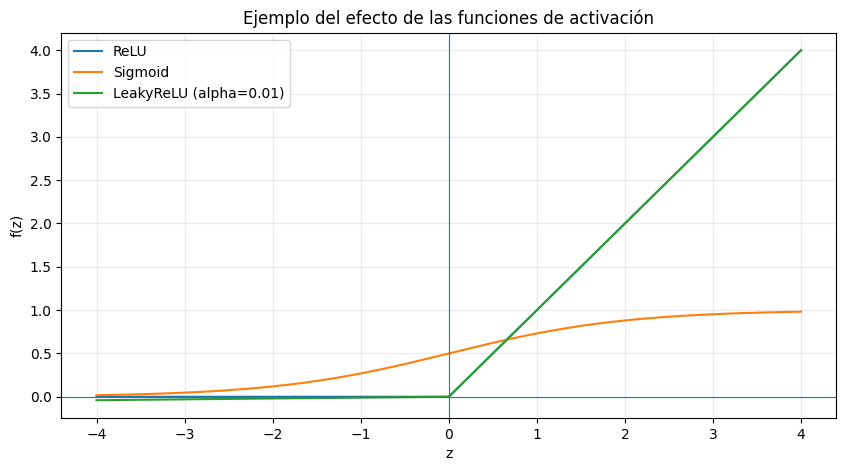

In [4]:
def relu_manual(z):
    return np.maximum(0, z)


def sigmoid_manual(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def leaky_relu_manual(z, alpha=0.01):
    """LeakyReLU: conserva una pequeña pendiente cuando z < 0."""
    return np.where(z >= 0, z, alpha * z)


def softmax_manual(z):
    z_shifted = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)


def sparse_categorical_crossentropy_explicit(y_true, y_prob):
    """Implementación explícita de Sparse Categorical Crossentropy."""
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    y_prob = tf.clip_by_value(tf.convert_to_tensor(y_prob, dtype=tf.float32), 1e-7, 1.0 - 1e-7)
    indices = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
    p_true = tf.gather_nd(y_prob, indices)
    return tf.reduce_mean(-tf.math.log(p_true))


# Ejemplo numérico: las tres activaciones reciben exactamente los mismos valores.
z_demo = np.array([[-2.0, -0.5, 0.0, 1.0, 3.0]])
print("Entrada z:", z_demo)
print("ReLU:", relu_manual(z_demo))
print("Sigmoid:", np.round(sigmoid_manual(z_demo), 4))
print("LeakyReLU:", np.round(leaky_relu_manual(z_demo), 4))

p_demo = softmax_manual(z_demo)
print("Softmax:", np.round(p_demo, 4))
print("Suma Softmax:", p_demo.sum(axis=1))

# Ejemplo explícito de pérdida: la pérdida depende de la probabilidad entregada a la clase correcta.
y_demo = np.array([2])
prob_demo = np.array([[0.05, 0.10, 0.70, 0.15]], dtype=np.float32)
loss_demo = sparse_categorical_crossentropy_explicit(y_demo, prob_demo).numpy()
print(f"Pérdida explícita para clase real 2 con p=0.70: {loss_demo:.4f}")

# Visualización del efecto de las activaciones.
z_curve = np.linspace(-4, 4, 400)
plt.figure(figsize=(10, 5))
plt.plot(z_curve, relu_manual(z_curve), label="ReLU")
plt.plot(z_curve, sigmoid_manual(z_curve), label="Sigmoid")
plt.plot(z_curve, leaky_relu_manual(z_curve), label="LeakyReLU (alpha=0.01)")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("z")
plt.ylabel("f(z)")
plt.title("Ejemplo del efecto de las funciones de activación")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 4. Arquitectura MLP base

La arquitectura base utiliza:

- entrada de 784 características;
- Dense(128) + ReLU;
- Dense(64) + ReLU;
- Dense(10) + Softmax.

**Justificación:** ReLU se utiliza en capas ocultas porque permite gradientes más favorables que una activación saturante en este tipo de MLP. Softmax transforma las salidas en probabilidades cuya suma es 1, permitiendo seleccionar una de las 10 clases.

In [5]:
def build_mlp(
    activation="relu",
    loss_name="sparse_categorical_crossentropy",
    dropout_rate=0.0,
    l2_rate=0.0,
    batch_norm=False,
    learning_rate=0.001
):
    model = keras.Sequential(name="MLP_Fashion_MNIST")
    model.add(layers.Input(shape=(784,)))

    for units in [128, 64]:
        model.add(
            layers.Dense(
                units,
                kernel_regularizer=regularizers.l2(l2_rate) if l2_rate > 0 else None
            )
        )
        if batch_norm:
            model.add(layers.BatchNormalization())

        # LeakyReLU se implementa explícitamente como capa para evitar
        # depender de una cadena de activación ambigua.
        if activation == "leaky_relu":
            model.add(layers.LeakyReLU(negative_slope=0.01))
        else:
            model.add(layers.Activation(activation))

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Softmax convierte los logits en probabilidades de las 10 clases.
    model.add(layers.Dense(10, activation="softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    # La pérdida por defecto es una implementación explícita de
    # Sparse Categorical Crossentropy. Las otras dos se mantienen para
    # el experimento controlado de comparación.
    if loss_name == "mse":
        loss = keras.losses.MeanSquaredError()
    elif loss_name == "categorical_crossentropy":
        loss = keras.losses.CategoricalCrossentropy()
    else:
        loss = sparse_categorical_crossentropy_explicit

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )
    return model

base_model = build_mlp()
base_model.summary()


Model: "MLP_Fashion_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Función auxiliar de entrenamiento y evaluación

Para que las comparaciones sean consistentes, los experimentos utilizan la misma semilla, arquitectura base y conjunto de validación, modificando solamente el parámetro que se está estudiando.

Las métricas globales **Precision, Recall y F1** se calculan con promedio **macro**, de modo que cada clase tenga el mismo peso. Esto es especialmente útil para interpretar si el modelo funciona de forma equilibrada entre las 10 categorías. Además, se conserva Precision/Recall/F1 ponderado para complementar el análisis.

- **Precision:** de las predicciones realizadas como una clase, cuántas eran realmente de esa clase.
- **Recall:** de los ejemplos que realmente pertenecían a una clase, cuántos fueron recuperados correctamente.
- **F1:** media armónica entre Precision y Recall.
- **Accuracy:** proporción total de predicciones correctas.

En Fashion-MNIST las clases están balanceadas, por lo que macro y weighted serán cercanos, pero mostrar ambas permite explicar qué se está midiendo y evita interpretar Accuracy como si fuera suficiente por sí sola.


In [6]:
def evaluate_model(model, X, y):
    y_prob = model.predict(X, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    precision_macro = precision_score(y, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y, y_pred, average="macro", zero_division=0)

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_macro,
        "Recall": recall_macro,
        "F1-Score": f1_macro,
        "Precision Weighted": precision_score(y, y_pred, average="weighted", zero_division=0),
        "Recall Weighted": recall_score(y, y_pred, average="weighted", zero_division=0),
        "F1 Weighted": f1_score(y, y_pred, average="weighted", zero_division=0)
    }


def train_experiment(
    name,
    activation="relu",
    epochs=10,
    batch_size=128,
    learning_rate=0.001,
    loss_name="sparse_categorical_crossentropy",
    dropout_rate=0.0,
    l2_rate=0.0,
    batch_norm=False
):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_mlp(
        activation=activation,
        loss_name=loss_name,
        dropout_rate=dropout_rate,
        l2_rate=l2_rate,
        batch_norm=batch_norm,
        learning_rate=learning_rate
    )

    y_train_fit = y_train if loss_name == "sparse_categorical_crossentropy" else keras.utils.to_categorical(y_train, 10)
    y_val_fit = y_val if loss_name == "sparse_categorical_crossentropy" else keras.utils.to_categorical(y_val, 10)

    start = time.time()
    history = model.fit(
        X_train,
        y_train_fit,
        validation_data=(X_val, y_val_fit),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    elapsed = time.time() - start

    val_metrics = evaluate_model(model, X_val, y_val)
    train_accuracy = float(history.history["accuracy"][-1])
    val_accuracy = float(history.history["val_accuracy"][-1])

    result = {
        "Experimento": name,
        "Épocas": epochs,
        "Batch": batch_size,
        "Learning Rate": learning_rate,
        "Activación": activation,
        "Loss": loss_name,
        "Dropout": dropout_rate,
        "L2": l2_rate,
        "BatchNorm": batch_norm,
        "Train Accuracy": train_accuracy,
        "Val Accuracy": val_accuracy,
        "Generalization Gap": train_accuracy - val_accuracy,
        "Val Precision": val_metrics["Precision"],
        "Val Recall": val_metrics["Recall"],
        "Val F1": val_metrics["F1-Score"],
        "Val Precision Weighted": val_metrics["Precision Weighted"],
        "Val Recall Weighted": val_metrics["Recall Weighted"],
        "Val F1 Weighted": val_metrics["F1 Weighted"],
        "Tiempo (s)": elapsed
    }

    return model, history, result


def plot_histories(histories, metric="accuracy", title="Comparación de entrenamientos"):
    plt.figure(figsize=(10, 5))
    for label, history in histories.items():
        plt.plot(history.history[metric], label=f"{label} train")
        plt.plot(history.history[f"val_{metric}"], linestyle="--", label=f"{label} val")
    plt.xlabel("Época")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 6. Experimento 1 — Tamaño de Batch

Se modifica **solo el batch size**, manteniendo iguales la arquitectura, activación, loss, learning rate y número de épocas.

Esto permite analizar el efecto de procesar más o menos muestras antes de actualizar los pesos.

,Experimento,Batch,Val Accuracy,Val Precision,Val Recall,Val F1
0,Batch 32,32,0.8881,0.8929,0.8881,0.8890
1,Batch 128,128,0.8885,0.8909,0.8885,0.8894
2,Batch 256,256,0.8863,0.8890,0.8863,0.8867


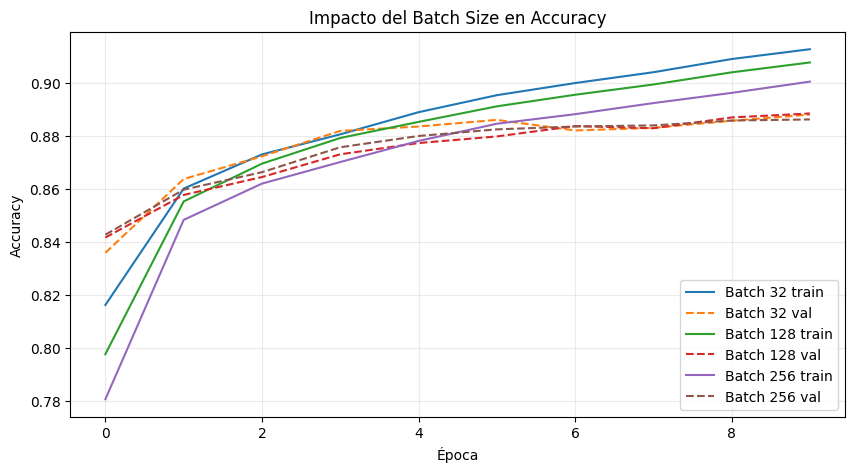

In [7]:
batch_values = [32, 128, 256]
batch_results = []
batch_histories = {}

for bs in batch_values:
    model, history, result = train_experiment(
        name=f"Batch {bs}",
        batch_size=bs,
        epochs=10
    )
    batch_results.append(result)
    batch_histories[f"Batch {bs}"] = history

df_batch = pd.DataFrame(batch_results)
display(df_batch[["Experimento", "Batch", "Val Accuracy", "Val Precision", "Val Recall", "Val F1"]].round(4))

plot_histories(batch_histories, "accuracy", "Impacto del Batch Size en Accuracy")

### Interpretación del Batch Size

La tabla permite identificar qué tamaño de lote produjo el mejor comportamiento de validación. La decisión debe basarse en los resultados observados, no en asumir que un batch específico siempre es superior.

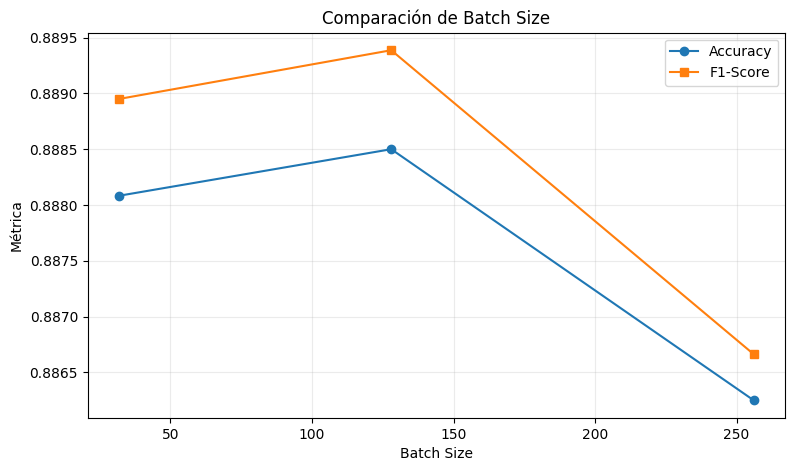

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_batch["Batch"], df_batch["Val Accuracy"], marker="o", label="Accuracy")
ax.plot(df_batch["Batch"], df_batch["Val F1"], marker="s", label="F1-Score")
ax.set_xlabel("Batch Size")
ax.set_ylabel("Métrica")
ax.set_title("Comparación de Batch Size")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 7. Experimento 2 — Tasa de aprendizaje

Se modifica **solo el learning rate**. Un learning rate demasiado alto puede producir actualizaciones inestables, mientras que uno demasiado bajo puede ralentizar la convergencia.

,Experimento,Learning Rate,Val Accuracy,Val Precision,Val Recall,Val F1
0,LR 0.0001,0.0001,0.8718,0.8724,0.8718,0.8712
1,LR 0.001,0.0010,0.8910,0.8916,0.8910,0.8911
2,LR 0.01,0.0100,0.8714,0.8743,0.8714,0.8721


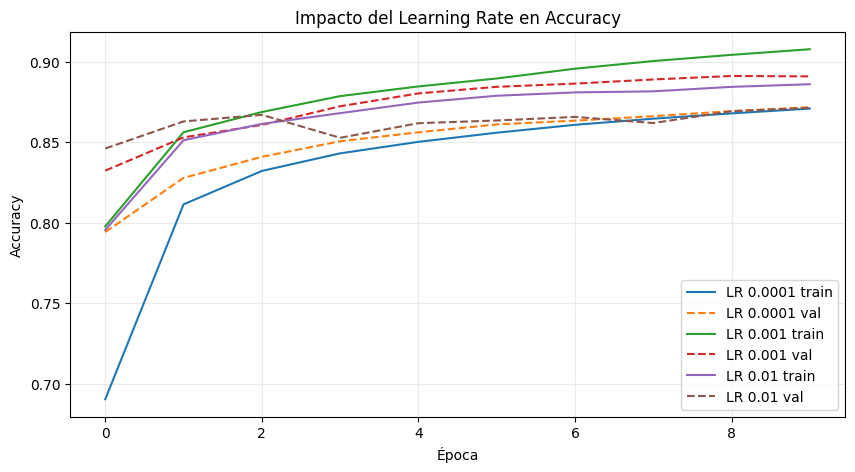

In [9]:
lr_values = [0.0001, 0.001, 0.01]
lr_results = []
lr_histories = {}

for lr in lr_values:
    model, history, result = train_experiment(
        name=f"LR {lr}",
        learning_rate=lr,
        batch_size=128,
        epochs=10
    )
    lr_results.append(result)
    lr_histories[f"LR {lr}"] = history

df_lr = pd.DataFrame(lr_results)
display(df_lr[["Experimento", "Learning Rate", "Val Accuracy", "Val Precision", "Val Recall", "Val F1"]].round(4))

plot_histories(lr_histories, "accuracy", "Impacto del Learning Rate en Accuracy")

## 8. Experimento 3 — Número de épocas

Se modifica **solo el número máximo de épocas**. Este experimento permite observar la evolución del aprendizaje y detectar señales de sobreajuste comparando las curvas de entrenamiento y validación.

,Experimento,Épocas,Val Accuracy,Val Precision,Val Recall,Val F1
0,5 épocas,5,0.8815,0.8841,0.8815,0.8820
1,10 épocas,10,0.8853,0.8881,0.8853,0.8861
2,15 épocas,15,0.8878,0.8889,0.8878,0.8871


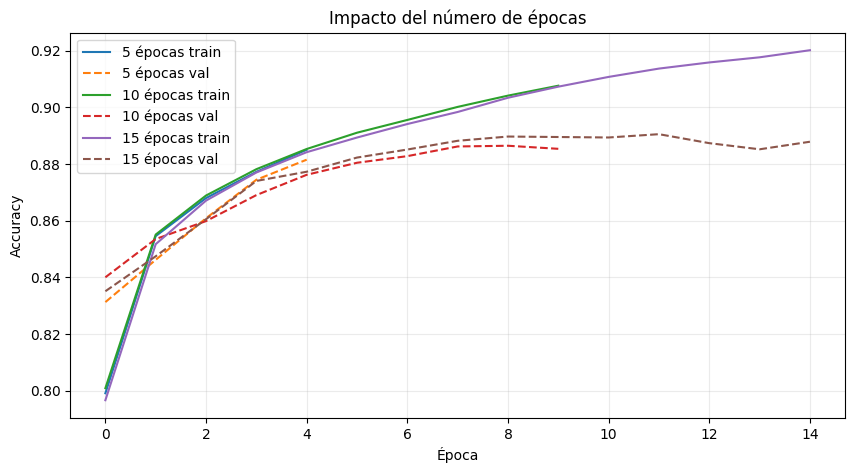

In [10]:
epoch_values = [5, 10, 15]
epoch_results = []
epoch_histories = {}

for ep in epoch_values:
    model, history, result = train_experiment(
        name=f"{ep} épocas",
        epochs=ep,
        batch_size=128
    )
    epoch_results.append(result)
    epoch_histories[f"{ep} épocas"] = history

df_epochs = pd.DataFrame(epoch_results)
display(df_epochs[["Experimento", "Épocas", "Val Accuracy", "Val Precision", "Val Recall", "Val F1"]].round(4))

plot_histories(epoch_histories, "accuracy", "Impacto del número de épocas")

## 9. Comparación de funciones de pérdida

Se comparan:

- **MSE**;
- **Categorical Crossentropy**;
- **Sparse Categorical Crossentropy**.

Para MSE y Categorical Crossentropy las etiquetas se convierten a One-Hot. Para Sparse Categorical Crossentropy se mantienen como enteros.

La comparación principal se realiza con Accuracy, Precision, Recall y F1-Score, porque las pérdidas pueden estar expresadas en escalas diferentes.

,Experimento,Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,MSE,mse,0.8815,0.8844,0.8815,0.8818
1,Categorical Crossentropy,categorical_crossentropy,0.8866,0.8899,0.8866,0.8875
2,Sparse Categorical Crossentropy,sparse_categorical_crossentropy,0.8880,0.8899,0.8880,0.8886


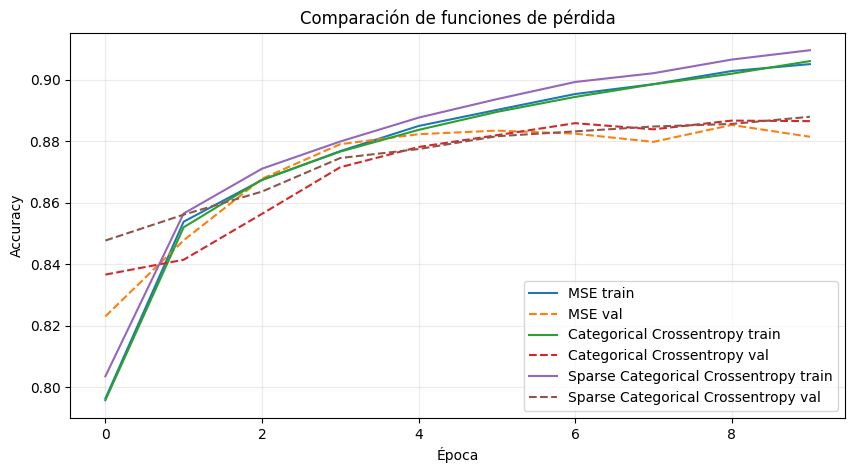

In [11]:
loss_values = [
    ("MSE", "mse"),
    ("Categorical Crossentropy", "categorical_crossentropy"),
    ("Sparse Categorical Crossentropy", "sparse_categorical_crossentropy")
]

loss_results = []
loss_histories = {}

for label, loss_name in loss_values:
    model, history, result = train_experiment(
        name=label,
        loss_name=loss_name,
        epochs=10,
        batch_size=128
    )
    loss_results.append(result)
    loss_histories[label] = history

df_loss = pd.DataFrame(loss_results)
display(df_loss[[
    "Experimento", "Loss", "Val Accuracy",
    "Val Precision", "Val Recall", "Val F1"
]].round(4))

plot_histories(loss_histories, "accuracy", "Comparación de funciones de pérdida")

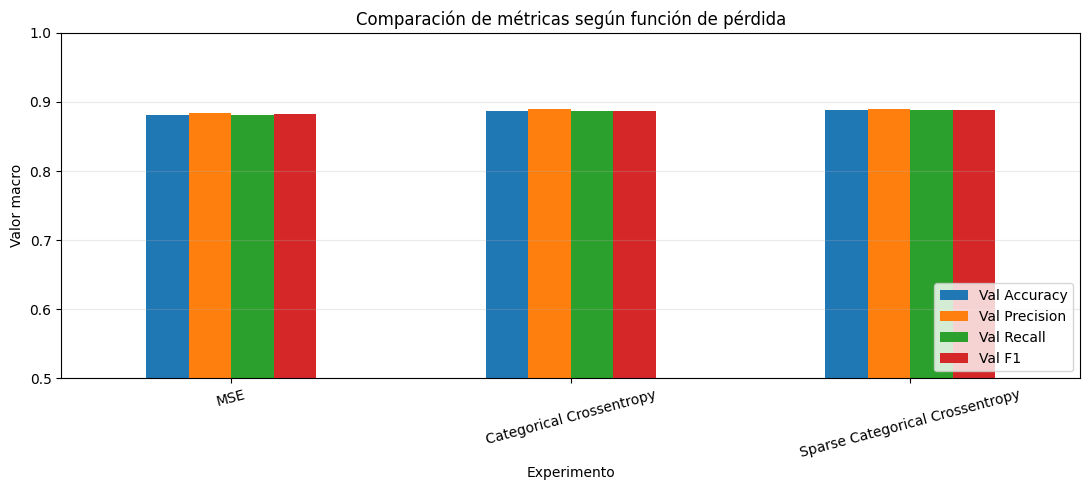

Comparación Precision vs Recall para las funciones de pérdida:


,Experimento,Val Precision,Val Recall,Val F1
2,Sparse Categorical Crossentropy,0.8899,0.8880,0.8886
1,Categorical Crossentropy,0.8899,0.8866,0.8875
0,MSE,0.8844,0.8815,0.8818


In [12]:
metrics_to_plot = ["Val Accuracy", "Val Precision", "Val Recall", "Val F1"]
plot_df = df_loss.set_index("Experimento")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Valor macro")
ax.set_title("Comparación de métricas según función de pérdida")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Comparación Precision vs Recall para las funciones de pérdida:")
display(df_loss[["Experimento", "Val Precision", "Val Recall", "Val F1"]].sort_values("Val F1", ascending=False).round(4))


### Justificación de la función de pérdida

Para este problema multiclase, **Sparse Categorical Crossentropy + Softmax** resulta conceptualmente apropiada porque cada imagen pertenece a una sola clase y las etiquetas están representadas como enteros. La tabla y el gráfico anterior permiten comprobar si esa elección también entrega un comportamiento competitivo en los datos.

## 10. Comparación de funciones de activación

Se comparan **ReLU, Sigmoid y LeakyReLU** manteniendo constantes los demás parámetros.

- **ReLU:** `max(0,z)`. Para valores positivos conserva el gradiente y para valores negativos entrega 0.
- **Sigmoid:** comprime los valores a `[0,1]`; en valores muy positivos o negativos puede saturarse y producir gradientes pequeños.
- **LeakyReLU:** utiliza una pendiente pequeña para `z < 0` (`alpha=0.01`), por lo que conserva una señal de gradiente en la zona negativa.

La implementación de LeakyReLU es explícita en `build_mlp` mediante `layers.LeakyReLU(negative_slope=0.01)`. Además, la sección 3 muestra numérica y gráficamente cómo cambia la salida de cada función ante la misma entrada.


,Experimento,Activación,Val Accuracy,Val Precision,Val Recall,Val F1
0,relu,relu,0.8859,0.8873,0.8859,0.8857
1,sigmoid,sigmoid,0.8868,0.8877,0.8868,0.8864
2,leaky_relu,leaky_relu,0.8909,0.8912,0.8909,0.8907


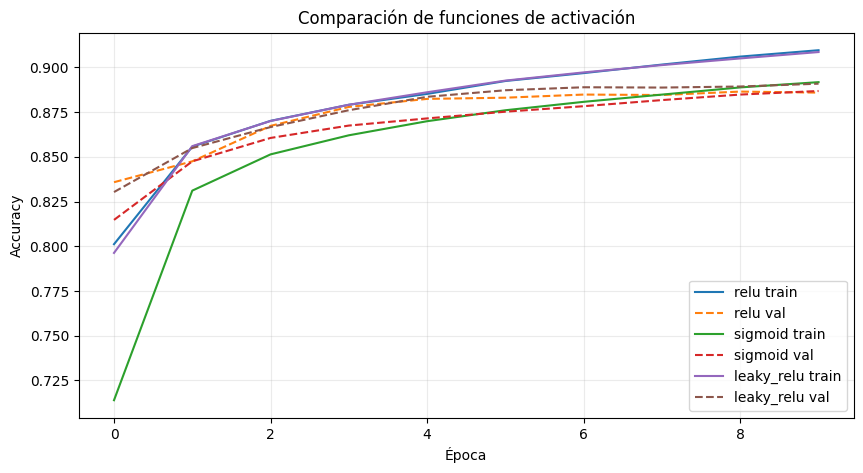

In [13]:
activation_values = ["relu", "sigmoid", "leaky_relu"]
activation_results = []
activation_histories = {}

for activation in activation_values:
    model, history, result = train_experiment(
        name=activation,
        activation=activation,
        epochs=10,
        batch_size=128
    )
    activation_results.append(result)
    activation_histories[activation] = history

df_activation = pd.DataFrame(activation_results)
display(df_activation[[
    "Experimento", "Activación", "Val Accuracy",
    "Val Precision", "Val Recall", "Val F1"
]].round(4))

plot_histories(
    activation_histories,
    "accuracy",
    "Comparación de funciones de activación"
)

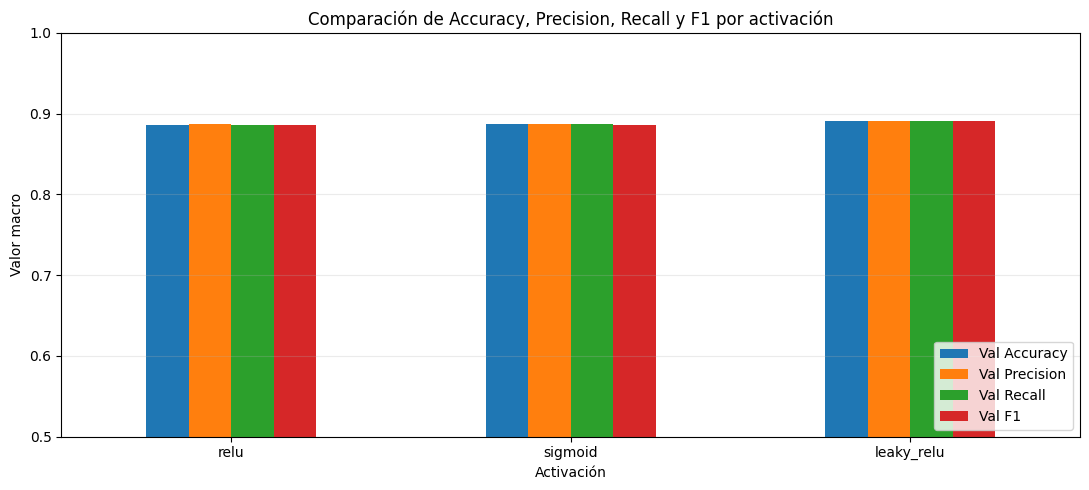

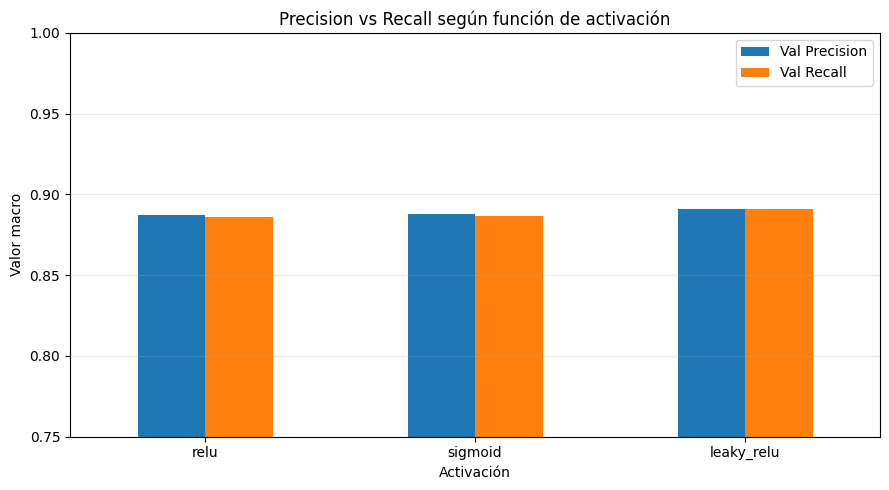

Brecha Precision-Recall por activación:


,Activación,Val Precision,Val Recall,Brecha abs.
2,leaky_relu,0.8912,0.8909,0.0003
1,sigmoid,0.8877,0.8868,0.0008
0,relu,0.8873,0.8859,0.0013


In [14]:
plot_df = df_activation.set_index("Activación")[[
    "Val Accuracy", "Val Precision", "Val Recall", "Val F1"
]]
ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Valor macro")
ax.set_title("Comparación de Accuracy, Precision, Recall y F1 por activación")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Gráfico específico de Precision vs Recall para responder directamente a la rúbrica.
pr_df = df_activation.set_index("Activación")[["Val Precision", "Val Recall"]]
ax = pr_df.plot(kind="bar", figsize=(9, 5))
ax.set_ylim(0.75, 1.0)
ax.set_ylabel("Valor macro")
ax.set_title("Precision vs Recall según función de activación")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Brecha Precision-Recall por activación:")
comparison_pr = df_activation[["Activación", "Val Precision", "Val Recall"]].copy()
comparison_pr["Brecha abs."] = (comparison_pr["Val Precision"] - comparison_pr["Val Recall"]).abs()
display(comparison_pr.sort_values("Brecha abs.").round(4))


## 11. Optimización y regularización: con y sin técnicas

Se compara un modelo base contra configuraciones que incorporan:

1. Dropout;
2. regularización L2;
3. Batch Normalization + Dropout.

El objetivo es observar el impacto de estas técnicas sobre la estabilidad y generalización. No se asume que agregar regularización siempre aumentará el accuracy: su utilidad depende de la relación entre capacidad del modelo y sobreajuste.

,Experimento,Dropout,L2,BatchNorm,Train Accuracy,Val Accuracy,Generalization Gap,Val Precision,Val Recall,Val F1
0,Base,0.0,0.0000,False,0.9071,0.8867,0.0204,0.8891,0.8868,0.8872
1,Dropout 0.2,0.2,0.0000,False,0.8851,0.8829,0.0022,0.8854,0.8829,0.8820
2,L2,0.0,0.0001,False,0.9022,0.8803,0.0219,0.8834,0.8803,0.8810
3,BatchNorm + Dropout,0.2,0.0000,True,0.8973,0.8900,0.0073,0.8901,0.8900,0.8885
4,Optimizado (Dropout + L2 + BN),0.2,0.0001,True,0.8917,0.8832,0.0086,0.8846,0.8832,0.8825


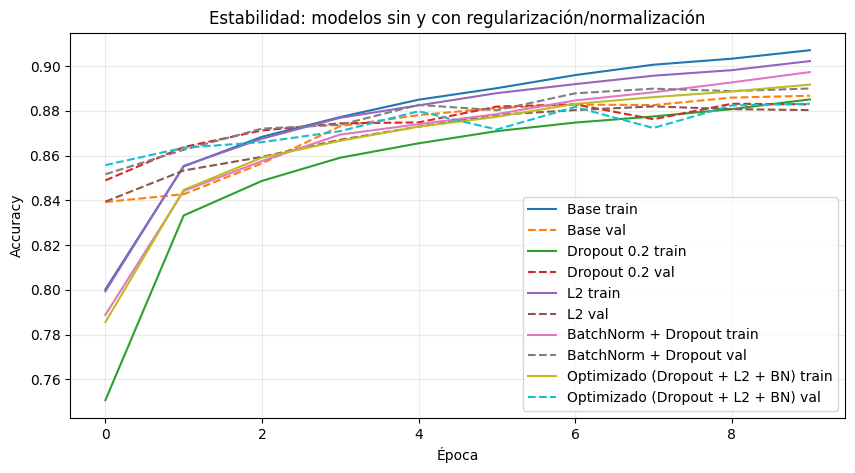

In [15]:
reg_configs = [
    ("Base", 0.0, 0.0, False),
    ("Dropout 0.2", 0.2, 0.0, False),
    ("L2", 0.0, 1e-4, False),
    ("BatchNorm + Dropout", 0.2, 0.0, True),
    ("Optimizado (Dropout + L2 + BN)", 0.2, 1e-4, True)
]

reg_results = []
reg_histories = {}

for name, dropout, l2_rate, bn in reg_configs:
    model, history, result = train_experiment(
        name=name,
        epochs=10,
        batch_size=128,
        dropout_rate=dropout,
        l2_rate=l2_rate,
        batch_norm=bn
    )
    reg_results.append(result)
    reg_histories[name] = history

df_reg = pd.DataFrame(reg_results)
display(df_reg[[
    "Experimento", "Dropout", "L2", "BatchNorm",
    "Train Accuracy", "Val Accuracy", "Generalization Gap",
    "Val Precision", "Val Recall", "Val F1"
]].round(4))

plot_histories(
    reg_histories,
    "accuracy",
    "Estabilidad: modelos sin y con regularización/normalización"
)


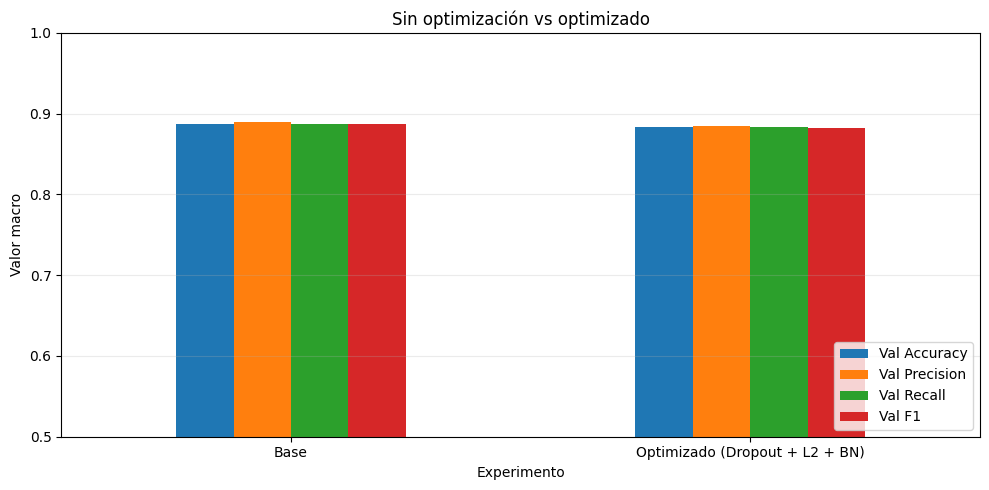

,Train Accuracy,Val Accuracy,Generalization Gap
Experimento,,,
Base,0.9071,0.8867,0.0204
Optimizado (Dropout + L2 + BN),0.8917,0.8832,0.0086


Cambio en Val Accuracy: -0.0036
Cambio en Val F1: -0.0047
Cambio en brecha train-validation: -0.0118


In [16]:
# Comparación directa solicitada por la rúbrica: sin optimización vs optimizado.
comparison_labels = ["Base", "Optimizado (Dropout + L2 + BN)"]
comparison = df_reg[df_reg["Experimento"].isin(comparison_labels)].set_index("Experimento")

metric_plot = comparison[["Val Accuracy", "Val Precision", "Val Recall", "Val F1"]]
ax = metric_plot.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Valor macro")
ax.set_title("Sin optimización vs optimizado")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# La brecha train-validation ayuda a discutir estabilidad/generalización sin asumir que
# una técnica de regularización necesariamente mejora todas las métricas.
stability = comparison[["Train Accuracy", "Val Accuracy", "Generalization Gap"]]
display(stability.round(4))

base_row = comparison.loc["Base"]
opt_row = comparison.loc["Optimizado (Dropout + L2 + BN)"]
print(f"Cambio en Val Accuracy: {(opt_row['Val Accuracy'] - base_row['Val Accuracy']):+.4f}")
print(f"Cambio en Val F1: {(opt_row['Val F1'] - base_row['Val F1']):+.4f}")
print(f"Cambio en brecha train-validation: {(opt_row['Generalization Gap'] - base_row['Generalization Gap']):+.4f}")


## 12. Tabla comparativa de todos los experimentos

Esta tabla resume las pruebas principales y permite justificar la configuración final a partir de evidencia experimental.

In [17]:
summary_tables = []
for df in [df_batch, df_lr, df_epochs, df_loss, df_activation, df_reg]:
    summary_tables.append(
        df[["Experimento", "Val Accuracy", "Val Precision", "Val Recall", "Val F1", "Generalization Gap"]]
    )

df_all = pd.concat(summary_tables, ignore_index=True)
display(df_all.sort_values("Val F1", ascending=False).head(20).round(4))


,Experimento,Val Accuracy,Val Precision,Val Recall,Val F1,Generalization Gap
4,LR 0.001,0.8910,0.8916,0.8910,0.8911,0.0169
14,leaky_relu,0.8909,0.8912,0.8909,0.8907,0.0177
1,Batch 128,0.8885,0.8909,0.8885,0.8894,0.0193
0,Batch 32,0.8881,0.8929,0.8881,0.8890,0.0247
11,Sparse Categorical Crossentropy,0.8880,0.8899,0.8880,0.8886,0.0216
18,BatchNorm + Dropout,0.8900,0.8901,0.8900,0.8885,0.0073
10,Categorical Crossentropy,0.8866,0.8899,0.8866,0.8875,0.0195
15,Base,0.8867,0.8891,0.8868,0.8872,0.0204
8,15 épocas,0.8878,0.8889,0.8878,0.8871,0.0323
2,Batch 256,0.8863,0.8890,0.8863,0.8867,0.0143


## 13. Selección de configuración final

La configuración final se construye a partir de los experimentos de validación. Como criterio principal se utiliza **F1-Score macro**, acompañado por Accuracy, Precision y Recall.

Se selecciona el mejor valor observado para **batch size, learning rate, número de épocas, activación y configuración de regularización**. Es importante aclarar que combinar los mejores valores individuales produce una **configuración compuesta**: la combinación completa se vuelve a evaluar en validación antes de utilizar el conjunto de prueba.

El conjunto de prueba permanece separado hasta la evaluación final, evitando utilizarlo para decidir los hiperparámetros.


In [18]:
# Mejores valores observados en cada experimento controlado.
best_batch = int(df_batch.loc[df_batch["Val F1"].idxmax(), "Batch"])
best_lr = float(df_lr.loc[df_lr["Val F1"].idxmax(), "Learning Rate"])
best_epochs = int(df_epochs.loc[df_epochs["Val F1"].idxmax(), "Épocas"])
best_activation = str(df_activation.loc[df_activation["Val F1"].idxmax(), "Activación"])
best_reg_row = df_reg.loc[df_reg["Val F1"].idxmax()]

best_dropout = float(best_reg_row["Dropout"])
best_l2 = float(best_reg_row["L2"])
best_bn = bool(best_reg_row["BatchNorm"])

print("Configuración compuesta seleccionada por F1 macro de validación:")
print("Batch:", best_batch)
print("Learning rate:", best_lr)
print("Épocas:", best_epochs)
print("Activación:", best_activation)
print("Dropout:", best_dropout)
print("L2:", best_l2)
print("Batch Normalization:", best_bn)
print("Configuración de regularización seleccionada:", best_reg_row["Experimento"])


Configuración compuesta seleccionada por F1 macro de validación:
Batch: 128
Learning rate: 0.001
Épocas: 15
Activación: leaky_relu
Dropout: 0.2
L2: 0.0
Batch Normalization: True
Configuración de regularización seleccionada: BatchNorm + Dropout


## 14. Entrenamiento final y evaluación en Test

Una vez definida la configuración mediante validación, se entrena nuevamente el modelo y se evalúa el conjunto de prueba, que no fue utilizado para seleccionar hiperparámetros.

Se presentan Accuracy, Precision, Recall y F1-Score, además de la matriz de confusión y el reporte por clase.

,Métrica,Modelo Final (validación)
0,Accuracy,0.8893
1,Precision,0.8906
2,Recall,0.8893
3,F1-Score,0.8880


Resultados en TEST — conjunto reservado:


,Métrica,Valor
0,Accuracy,0.8748
1,Precision,0.8753
2,Recall,0.8748
3,F1-Score,0.8735


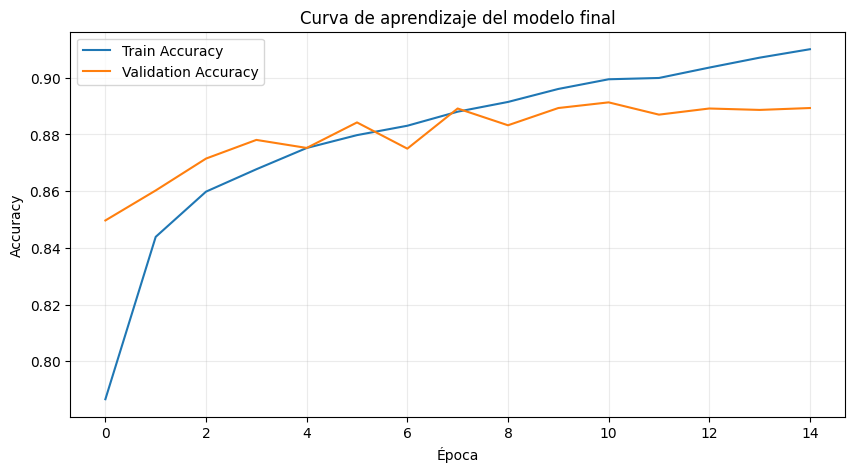

In [19]:
final_model, final_history, final_result = train_experiment(
    name="Modelo Final",
    activation=best_activation,
    epochs=best_epochs,
    batch_size=best_batch,
    learning_rate=best_lr,
    loss_name="sparse_categorical_crossentropy",
    dropout_rate=best_dropout,
    l2_rate=best_l2,
    batch_norm=best_bn
)

val_final_metrics = evaluate_model(final_model, X_val, y_val)
test_metrics = evaluate_model(final_model, X_test, y_test)

# Comparación de validación del modelo final contra el mejor experimento individual.
df_final_validation = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Modelo Final (validación)": [
        val_final_metrics["Accuracy"], val_final_metrics["Precision"],
        val_final_metrics["Recall"], val_final_metrics["F1-Score"]
    ]
})

display(df_final_validation.round(4))

print("Resultados en TEST — conjunto reservado:")
df_test_metrics = pd.DataFrame(
    {"Métrica": list(test_metrics.keys())[:4], "Valor": list(test_metrics.values())[:4]}
)
display(df_test_metrics.round(4))

plt.figure(figsize=(10, 5))
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.plot(final_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje del modelo final")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 15. Matriz de confusión

La matriz de confusión permite identificar qué clases se confunden entre sí. Esto complementa las métricas globales y ayuda a explicar por qué Precision, Recall o F1 no necesariamente son idénticos entre categorías.

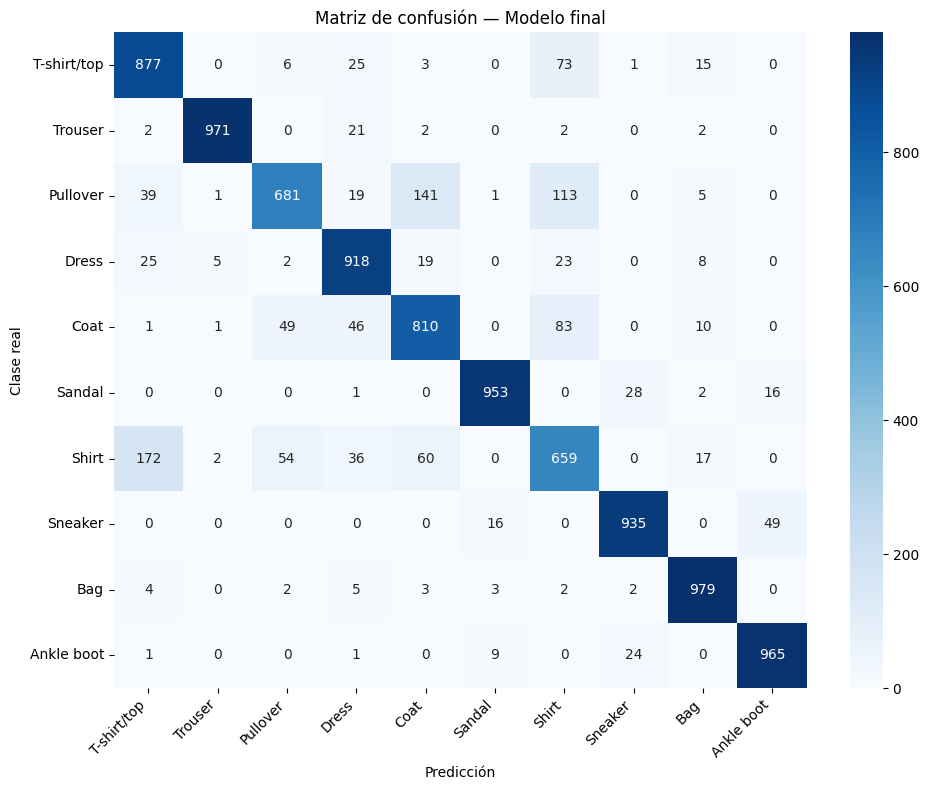

,Precision,Recall,F1,Support
T-shirt/top,0.7823,0.877,0.8270,1000.0
Trouser,0.9908,0.971,0.9808,1000.0
Pullover,0.8577,0.681,0.7592,1000.0
Dress,0.8563,0.918,0.8861,1000.0
Coat,0.7803,0.810,0.7949,1000.0
Sandal,0.9705,0.953,0.9617,1000.0
Shirt,0.6901,0.659,0.6742,1000.0
Sneaker,0.9444,0.935,0.9397,1000.0
Bag,0.9432,0.979,0.9607,1000.0
Ankle boot,0.9369,0.965,0.9507,1000.0


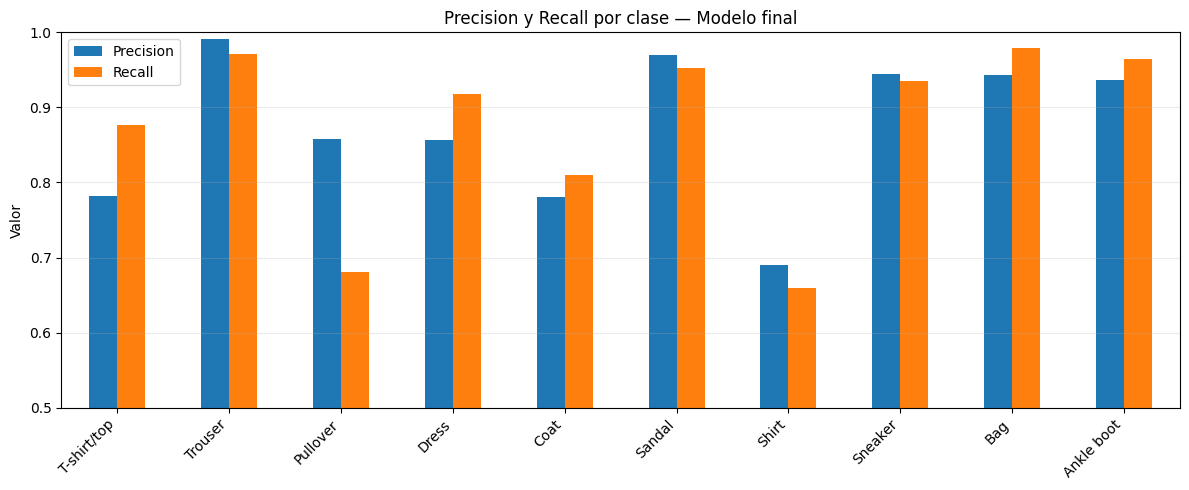

Principales errores de clasificación:


,Clase real,Predicha como,Cantidad
34,Shirt,T-shirt/top,172
14,Pullover,Coat,141
16,Pullover,Shirt,113
28,Coat,Shirt,83
3,T-shirt/top,Shirt,73
38,Shirt,Coat,60
36,Shirt,Pullover,54
26,Coat,Pullover,49
41,Sneaker,Ankle boot,49
27,Coat,Dress,46


In [20]:
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión — Modelo final")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Métricas por clase: permite identificar dónde se pierde Precision o Recall.
report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).T.loc[class_names, ["precision", "recall", "f1-score", "support"]]
report_df = report_df.rename(columns={"precision": "Precision", "recall": "Recall", "f1-score": "F1", "support": "Support"})

display(report_df.round(4))

# Precision y Recall por clase.
ax = report_df[["Precision", "Recall"]].plot(kind="bar", figsize=(12, 5))
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Valor")
ax.set_title("Precision y Recall por clase — Modelo final")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Principales pares de confusión, excluyendo la diagonal.
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
confusion_pairs = []
for i, j in np.argwhere(cm_no_diag > 0):
    confusion_pairs.append({
        "Clase real": class_names[i],
        "Predicha como": class_names[j],
        "Cantidad": int(cm[i, j])
    })

top_confusions = pd.DataFrame(confusion_pairs).sort_values("Cantidad", ascending=False).head(10)
print("Principales errores de clasificación:")
display(top_confusions)


## 16. Ejemplos de predicciones

Se muestran imágenes clasificadas correctamente y algunas incorrectamente. Esto entrega evidencia visual del comportamiento del modelo y ayuda a interpretar los hallazgos.

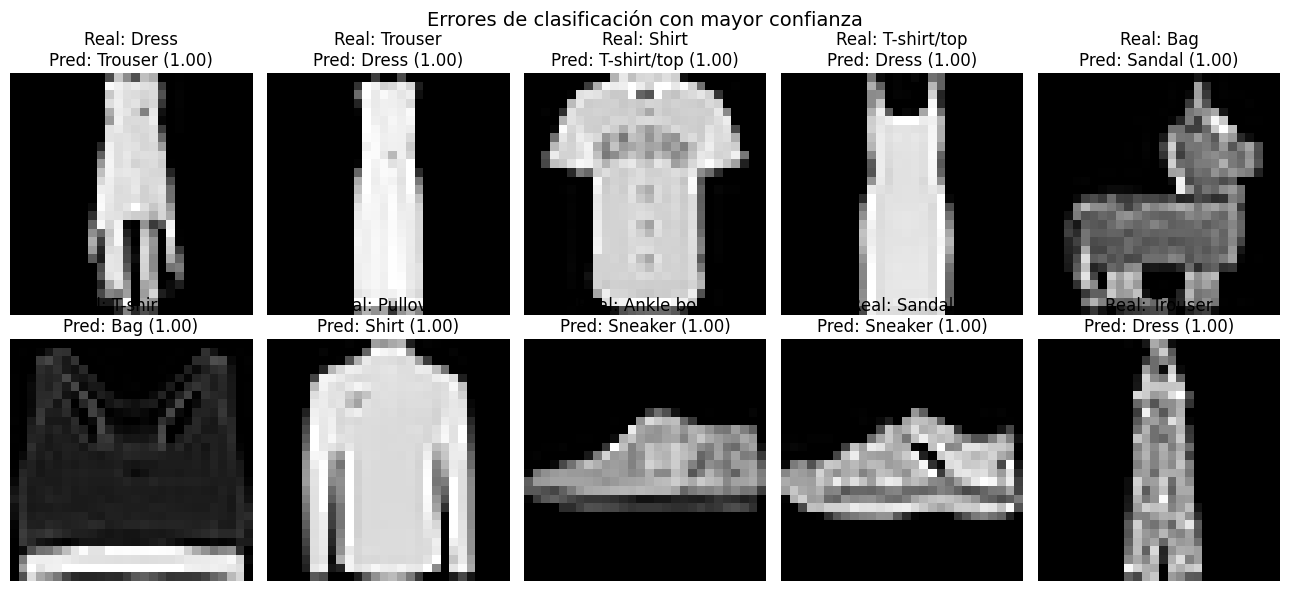

Interpretación: estos ejemplos permiten discutir que parte del error proviene de similitudes visuales entre categorías, especialmente prendas de apariencia cercana.


In [21]:
correct = np.where(y_test_pred == y_test)[0]
incorrect = np.where(y_test_pred != y_test)[0]

# Mostramos errores con mayor confianza: son casos especialmente informativos
# porque el modelo está seguro de una clase que finalmente resulta incorrecta.
incorrect_conf = y_test_prob[incorrect].max(axis=1)
order = np.argsort(incorrect_conf)[::-1]
selected_incorrect = incorrect[order[:10]]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, idx in zip(axes.ravel(), selected_incorrect):
    pred_conf = float(y_test_prob[idx, y_test_pred[idx]])
    ax.imshow(X_test_raw[idx], cmap="gray")
    ax.set_title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_test_pred[idx]]} ({pred_conf:.2f})"
    )
    ax.axis("off")
plt.suptitle("Errores de clasificación con mayor confianza", fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretación: estos ejemplos permiten discutir que parte del error proviene de similitudes visuales entre categorías, especialmente prendas de apariencia cercana.")


## 17. ¿Cómo mejorar Precision y Recall?

La mejora se interpreta a partir de los resultados reales del modelo, no como una lista genérica de técnicas.

- Si una clase presenta **Precision baja**, el modelo está asignando esa etiqueta a ejemplos que pertenecen a otras clases; conviene revisar en la matriz de confusión qué clases están generando esos falsos positivos.
- Si una clase presenta **Recall bajo**, el modelo está dejando sin detectar ejemplos que realmente pertenecen a esa clase; las filas de la matriz de confusión muestran hacia qué categorías se están desviando.
- Una brecha grande entre `Train Accuracy` y `Val Accuracy` sugiere revisar sobreajuste; en ese caso Dropout, L2 o Batch Normalization pueden ayudar a mejorar generalización.
- Si entrenamiento y validación permanecen relativamente bajos, el problema puede ser de capacidad/representación. En esta evaluación se mantiene una **MLP**, por lo que no se reemplaza por una CNN.

Los gráficos de Precision/Recall por clase y la tabla de principales confusiones permiten relacionar cada propuesta de mejora con un error concreto del modelo.


# 18. Conclusiones

Las conclusiones se generan a partir de los resultados obtenidos durante la ejecución del notebook. De esta forma, si cambian los resultados al volver a entrenar el modelo, el texto se actualiza y no queda una conclusión escrita manualmente que pueda contradecir las gráficas.


In [22]:
from IPython.display import display, Markdown

# Resultados clave obtenidos durante ESTA ejecución.
batch_best = df_batch.loc[df_batch["Val F1"].idxmax()]
lr_best = df_lr.loc[df_lr["Val F1"].idxmax()]
epoch_best = df_epochs.loc[df_epochs["Val F1"].idxmax()]
loss_best = df_loss.loc[df_loss["Val F1"].idxmax()]
activation_best = df_activation.loc[df_activation["Val F1"].idxmax()]
reg_best = df_reg.loc[df_reg["Val F1"].idxmax()]

base_opt = df_reg[df_reg["Experimento"].isin(["Base", "Optimizado (Dropout + L2 + BN)"])].set_index("Experimento")
base_f1 = float(base_opt.loc["Base", "Val F1"])
opt_f1 = float(base_opt.loc["Optimizado (Dropout + L2 + BN)", "Val F1"])
base_gap = float(base_opt.loc["Base", "Generalization Gap"])
opt_gap = float(base_opt.loc["Optimizado (Dropout + L2 + BN)", "Generalization Gap"])

# Principal confusión del test.
cm_tmp = cm.copy()
np.fill_diagonal(cm_tmp, 0)
i_top, j_top = np.unravel_index(np.argmax(cm_tmp), cm_tmp.shape)
top_error_count = int(cm_tmp[i_top, j_top])

worst_recall_class = report_df["Recall"].idxmin()
worst_precision_class = report_df["Precision"].idxmin()

final_acc = float(test_metrics["Accuracy"])
final_precision = float(test_metrics["Precision"])
final_recall = float(test_metrics["Recall"])
final_f1 = float(test_metrics["F1-Score"])

conclusions = f"""
### 1. Datos y preprocesamiento
Fashion-MNIST se trabajó con imágenes de 28×28 píxeles transformadas a 784 características y normalizadas a [0,1]. El conjunto se separó en entrenamiento, validación y prueba, manteniendo el conjunto de prueba reservado para la evaluación final.

### 2. Hiperparámetros
En los experimentos controlados, el mejor F1 macro observado para **batch size** fue con `Batch {int(batch_best['Batch'])}`, con F1 de validación **{batch_best['Val F1']:.4f}**. Para **learning rate**, el mejor resultado fue `LR {lr_best['Learning Rate']}`, con F1 **{lr_best['Val F1']:.4f}**. En **número de épocas**, el mejor resultado observado fue **{int(epoch_best['Épocas'])} épocas**, con F1 **{epoch_best['Val F1']:.4f}**. Por lo tanto, estos valores se seleccionaron como evidencia de validación y no por asumir que existe un valor universalmente mejor.

### 3. Función de pérdida
La comparación entregó como mejor F1 de validación a **{loss_best['Experimento']}**, con F1 **{loss_best['Val F1']:.4f}**, Precision **{loss_best['Val Precision']:.4f}** y Recall **{loss_best['Val Recall']:.4f}**. La pérdida utilizada en el modelo final es Sparse Categorical Crossentropy, coherente con etiquetas enteras y un problema multiclase de una sola clase correcta por imagen. La implementación explícita permite mostrar cómo la probabilidad asignada a la clase real se transforma en error.

### 4. Función de activación
La activación con mejor F1 de validación fue **{activation_best['Activación']}**, con F1 **{activation_best['Val F1']:.4f}**. Esta conclusión se basa en la tabla y el gráfico de comparación, mientras que los ejemplos de la sección 3 muestran la diferencia funcional entre ReLU, Sigmoid y LeakyReLU. No se afirma que una activación sea siempre superior: en este dataset y bajo esta configuración fue la que obtuvo ese resultado.

### 5. Sin optimización vs optimizado
El modelo **Base** obtuvo F1 de validación **{base_f1:.4f}**, mientras que la configuración **Optimizado (Dropout + L2 + BN)** obtuvo **{opt_f1:.4f}**. La brecha train-validation pasó de **{base_gap:.4f}** a **{opt_gap:.4f}**. Esto permite distinguir dos efectos: cambio en desempeño y cambio en generalización. Si la métrica optimizada no supera a la base, el resultado no se oculta: significa que, bajo estas condiciones, las técnicas añadidas no produjeron una mejora global de F1, aunque pueden modificar la estabilidad o la brecha entre entrenamiento y validación.

### 6. Modelo final y selección
La configuración final combina los mejores valores individuales observados para batch, learning rate, épocas, activación y regularización. La combinación completa se volvió a entrenar y evaluar antes de utilizar el test. Esta selección se justifica por resultados de validación y no por una conclusión previa.

### 7. Evaluación final en test
En el conjunto de prueba, el modelo obtuvo **Accuracy = {final_acc:.4f}**, **Precision macro = {final_precision:.4f}**, **Recall macro = {final_recall:.4f}** y **F1 macro = {final_f1:.4f}**. Estas cifras representan el desempeño sobre datos que no se utilizaron para escoger los hiperparámetros.

### 8. Errores de clasificación
La clase con menor Recall fue **{worst_recall_class}**, mientras que la de menor Precision fue **{worst_precision_class}**. El principal par de confusión fue **{class_names[i_top]} → {class_names[j_top]}**, con **{top_error_count}** casos. Esto muestra que el error no está distribuido de manera uniforme entre las categorías y que las confusiones entre prendas visualmente similares son una parte relevante del desempeño de la MLP.

### 9. Aprendizaje principal
El resultado más importante del experimento no es solamente una cifra de Accuracy: las pruebas muestran cómo cambios concretos en hiperparámetros, funciones y regularización modifican las métricas y las curvas de aprendizaje. La matriz de confusión y los ejemplos de errores complementan las métricas globales al mostrar **dónde** se concentra el error del modelo.
"""

display(Markdown(conclusions))



### 1. Datos y preprocesamiento
Fashion-MNIST se trabajó con imágenes de 28×28 píxeles transformadas a 784 características y normalizadas a [0,1]. El conjunto se separó en entrenamiento, validación y prueba, manteniendo el conjunto de prueba reservado para la evaluación final.

### 2. Hiperparámetros
En los experimentos controlados, el mejor F1 macro observado para **batch size** fue con `Batch 128`, con F1 de validación **0.8894**. Para **learning rate**, el mejor resultado fue `LR 0.001`, con F1 **0.8911**. En **número de épocas**, el mejor resultado observado fue **15 épocas**, con F1 **0.8871**. Por lo tanto, estos valores se seleccionaron como evidencia de validación y no por asumir que existe un valor universalmente mejor.

### 3. Función de pérdida
La comparación entregó como mejor F1 de validación a **Sparse Categorical Crossentropy**, con F1 **0.8886**, Precision **0.8899** y Recall **0.8880**. La pérdida utilizada en el modelo final es Sparse Categorical Crossentropy, coherente con etiquetas enteras y un problema multiclase de una sola clase correcta por imagen. La implementación explícita permite mostrar cómo la probabilidad asignada a la clase real se transforma en error.

### 4. Función de activación
La activación con mejor F1 de validación fue **leaky_relu**, con F1 **0.8907**. Esta conclusión se basa en la tabla y el gráfico de comparación, mientras que los ejemplos de la sección 3 muestran la diferencia funcional entre ReLU, Sigmoid y LeakyReLU. No se afirma que una activación sea siempre superior: en este dataset y bajo esta configuración fue la que obtuvo ese resultado.

### 5. Sin optimización vs optimizado
El modelo **Base** obtuvo F1 de validación **0.8872**, mientras que la configuración **Optimizado (Dropout + L2 + BN)** obtuvo **0.8825**. La brecha train-validation pasó de **0.0204** a **0.0086**. Esto permite distinguir dos efectos: cambio en desempeño y cambio en generalización. Si la métrica optimizada no supera a la base, el resultado no se oculta: significa que, bajo estas condiciones, las técnicas añadidas no produjeron una mejora global de F1, aunque pueden modificar la estabilidad o la brecha entre entrenamiento y validación.

### 6. Modelo final y selección
La configuración final combina los mejores valores individuales observados para batch, learning rate, épocas, activación y regularización. La combinación completa se volvió a entrenar y evaluar antes de utilizar el test. Esta selección se justifica por resultados de validación y no por una conclusión previa.

### 7. Evaluación final en test
En el conjunto de prueba, el modelo obtuvo **Accuracy = 0.8748**, **Precision macro = 0.8753**, **Recall macro = 0.8748** y **F1 macro = 0.8735**. Estas cifras representan el desempeño sobre datos que no se utilizaron para escoger los hiperparámetros.

### 8. Errores de clasificación
La clase con menor Recall fue **Shirt**, mientras que la de menor Precision fue **Shirt**. El principal par de confusión fue **Shirt → T-shirt/top**, con **172** casos. Esto muestra que el error no está distribuido de manera uniforme entre las categorías y que las confusiones entre prendas visualmente similares son una parte relevante del desempeño de la MLP.

### 9. Aprendizaje principal
El resultado más importante del experimento no es solamente una cifra de Accuracy: las pruebas muestran cómo cambios concretos en hiperparámetros, funciones y regularización modifican las métricas y las curvas de aprendizaje. La matriz de confusión y los ejemplos de errores complementan las métricas globales al mostrar **dónde** se concentra el error del modelo.


## 19. Checklist de cumplimiento de la rúbrica

| Requisito | Evidencia en el notebook |
|---|---|
| Carga y preprocesamiento | Sección 2 |
| Visualización de datos | Sección 2.1 |
| MLP con TensorFlow/Keras | Sección 4 |
| Épocas, batch y learning rate | Secciones 6, 7 y 8 |
| Experimentos controlados | Secciones 6–11 |
| Funciones de activación, incluyendo LeakyReLU explícita | Secciones 3 y 10 |
| Función de pérdida explícita | Sección 3 y función `sparse_categorical_crossentropy_explicit` |
| Comparación de funciones de pérdida | Sección 9 |
| Comparación de Precision y Recall | Secciones 9, 10 y 15 |
| Dropout / L2 / BatchNorm | Sección 11 |
| Comparación sin optimización vs optimizado | Sección 11 |
| Accuracy / Precision / Recall / F1 | Secciones 5 y 14 |
| Matriz de confusión | Sección 15 |
| Ejemplos visuales de errores | Sección 16 |
| Análisis de causas de errores | Secciones 15–17 |
| Selección del modelo final basada en validación | Sección 13 |
| Conclusiones dependientes de resultados reales | Sección 18, generada dinámicamente |
